<a href="https://colab.research.google.com/github/NM-NISA/CVPR/blob/main/CNN_23_51392_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Introduction**

In this assignment, an image classification model was developed to identify different types of cars. The dataset consisted of images from 7 car categories: Audi, Hyundai Creta, Mahindra Scorpio, Rolls Royce, Swift, Tata Safari, and Toyota Innova.

The objective was to train a deep learning model that could accurately classify these images based on their visual features.

**2. Import Libraries**

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In this section, all necessary libraries required for the project were imported.

PyTorch was used for building and training the deep learning model, while NumPy and Matplotlib were used for data handling and visualization. OpenCV was used for reading images, and Scikit-learn was used for evaluation metrics.

**3. Setup Device**

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


**4. Download and Extract Dataset**

In [3]:
# Upload kaggle.json first
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nusratnisa","key":"36ea0f06668ec5ea6adbeaf888e62f7b"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d kshitij192/cars-image-dataset

with zipfile.ZipFile("cars-image-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

Dataset URL: https://www.kaggle.com/datasets/kshitij192/cars-image-dataset
License(s): GPL-2.0
100% 36.3M/36.3M [00:00<00:00, 110MB/s] 



The dataset was downloaded from Kaggle and extracted into the working directory.

It was organized into two main folders: training and testing. Each folder contained subfolders for each class, where images were stored according to their respective categories.

**5. Data Preprocessing & Augmentation**

In [5]:
# Train transform (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

# Validation/Test transform (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

# Load Dataset
train_dir = "data/Cars Dataset/train"
test_dir = "data/Cars Dataset/test"

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

print("Classes:", train_dataset.classes)
print("Number of classes:", len(train_dataset.classes))

Classes: ['Audi', 'Hyundai Creta', 'Mahindra Scorpio', 'Rolls Royce', 'Swift', 'Tata Safari', 'Toyota Innova']
Number of classes: 7


Before feeding the images into the model, preprocessing and data augmentation techniques were applied.

All images were resized to 224×224 pixels to match the input size required by the model.

Data augmentation techniques such as random rotation, flipping, and color adjustments were applied to increase data diversity and improve generalization.

Finally, images were normalized to stabilize and accelerate the training process.

**6. Split into Train / Validation / Test**

In [6]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])

# Apply test transform to validation
val_data.dataset.transform = test_transform

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

The dataset was split into 80% training and 20% validation using random sampling to ensure unbiased learning.

The validation set was assigned test transformations to avoid augmentation and ensure fair evaluation.

Data loaders were then created with batch size 32, where shuffling was enabled for training to improve learning and disabled for testing to maintain consistency.

In [7]:
print("Training dataset size: ", len(train_dataset))
print("Testing dataset size: ", len(test_dataset))

Training dataset size:  3352
Testing dataset size:  813


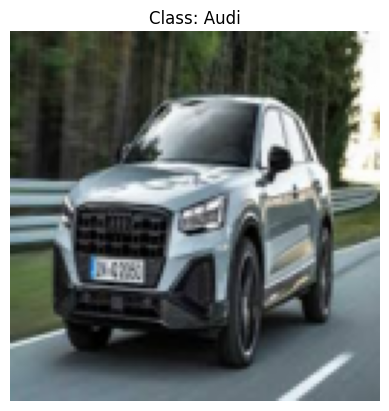

In [8]:
# Visualize a sample image
image, label = train_dataset[0]

# Denormalize
image = image * 0.5 + 0.5

# Clip values to valid range
image = torch.clamp(image, 0, 1)

# Convert tensor to numpy
image = image.permute(1, 2, 0)

plt.imshow(image)
plt.title(f"Class: {train_dataset.classes[label]}")
plt.axis("off")
plt.show()

A sample image from the dataset was displayed to verify that the data was loaded correctly.

Since normalization was applied, the image was converted back to its original range before visualization.

**7a. CNN Architecture (Without BatchNorm & Dropout)**

In [9]:
class CNN_Model1(nn.Module):
    def __init__(self, num_classes):
        super(CNN_Model1, self).__init__()

        self.conv = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 5
            nn.Conv2d(256, 512, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*4*4, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

The Model was created using Convolutional Layer, Rectified Linear Unit, and Max Pooling.

Batch Normalization & Dropout were avoided. By removing regularization techniques (Dropout) and training acceleration techniques (BatchNorm), the goal is to establish a baseline performance.

 This approach helps understand the dataset's complexity. If the simple model overfits, it confirms that techniques like Dropout are needed. If the model is slow to learn, it suggests that BatchNorm is required.

**7b. CNN Architecture (With BatchNorm & Dropout)**

In [10]:
class CNN_Model2(nn.Module):
    def __init__(self, num_classes):
        super(CNN_Model2, self).__init__()

        self.conv = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 5
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*4*4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

The model was extended by adding Batch Normalization & Dropout to improve the performace of the Basic CNN Model.

Based on the line nn.Linear(512*4*4, 512), this model expects an input image size of 128x128 pixels. After five rounds of MaxPool2d (which halves the dimensions each time), a 128x128 image is reduced to a 4x4 grid.

**8. Initialize Model**

In [11]:
model1 = CNN_Model1(num_classes=len(train_dataset.classes)).to(device)
print(model1)

CNN_Model1(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(

In [12]:
model2 = CNN_Model2(num_classes=len(train_dataset.classes)).to(device)
print(model2)

CNN_Model2(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

**9. Loss Function, Optimizer & Scheduler**

In [13]:
#Handle Class Imbalance
from collections import Counter

targets = [label for _, label in train_dataset]
class_counts = Counter(targets)

class_weights = [1.0/class_counts[i] for i in range(len(class_counts))]
class_weights = torch.tensor(class_weights).to(device)

# Applying Loss Function, Optimizer & Scheduler on Basic CNN Model
criterion1 = nn.CrossEntropyLoss(weight=class_weights)

optimizer1 = optim.Adam(model1.parameters(), lr=0.0001)

scheduler1 = optim.lr_scheduler.StepLR(optimizer1, step_size=7, gamma=0.5)

# Applying Loss Function, Optimizer & Scheduler on Improved CNN Model
criterion2 = nn.CrossEntropyLoss(weight=class_weights)

optimizer2 = optim.Adam(model2.parameters(), lr=0.0001)

scheduler2 = optim.lr_scheduler.StepLR(optimizer2, step_size=7, gamma=0.5)

The dataset contained an unequal number of images across different classes, which could lead to biased predictions.

To address this issue, class weights and weighted sampling techniques were applied.

This ensured that all classes were treated fairly during training and improved the model’s performance on underrepresented classes.

**10. Training Loop with Validation**

In [14]:
print("Model 1 Parameters:", sum(p.numel() for p in model1.parameters()))
print("Model 2 Parameters:", sum(p.numel() for p in model2.parameters()))

Model 1 Parameters: 5766983
Model 2 Parameters: 5768967


Several hyperparameters were carefully selected for training the model.
The number of epochs was set to 30 to allow sufficient learning while avoiding overfitting.

The batch size was set to 32 to balance computational efficiency and performance.

The learning rate was set to 0.0001 to ensure stable and gradual convergence.

The Adam optimizer was used for faster and adaptive learning.
These choices helped achieve a balance between performance and training efficiency.

In [15]:
# Train Basic CNN Model
print("CNN Model (Without BatchNorm & Dropout)")
num_epochs = 30

train_losses1, val_losses1 = [], []
train_accs1, val_accs1 = [], []

for epoch in range(num_epochs):
    model1.train()
    correct, total, train_loss1 = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer1.zero_grad()
        outputs = model1(images)
        loss = criterion1(outputs, labels)
        loss.backward()
        optimizer1.step()

        train_loss1 += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc1 = correct / total

    # Validation
    model1.eval()
    val_loss1, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model1(images)
            loss = criterion1(outputs, labels)

            val_loss1 += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc1 = correct / total

    scheduler1.step()

    train_losses1.append(train_loss1)
    val_losses1.append(val_loss1)
    train_accs1.append(train_acc1)
    val_accs1.append(val_acc1)

    print(f"Epoch {epoch+1}: Train Acc={train_acc1:.4f}, Val Acc={val_acc1:.4f}")

CNN Model (Without BatchNorm & Dropout)
Epoch 1: Train Acc=0.1552, Val Acc=0.1893
Epoch 2: Train Acc=0.2529, Val Acc=0.2653
Epoch 3: Train Acc=0.3301, Val Acc=0.2876
Epoch 4: Train Acc=0.3551, Val Acc=0.3934
Epoch 5: Train Acc=0.4174, Val Acc=0.4516
Epoch 6: Train Acc=0.4756, Val Acc=0.4426
Epoch 7: Train Acc=0.5211, Val Acc=0.4844
Epoch 8: Train Acc=0.5804, Val Acc=0.4888
Epoch 9: Train Acc=0.6270, Val Acc=0.5514
Epoch 10: Train Acc=0.6624, Val Acc=0.5440
Epoch 11: Train Acc=0.6856, Val Acc=0.4814
Epoch 12: Train Acc=0.7038, Val Acc=0.5618
Epoch 13: Train Acc=0.7378, Val Acc=0.5797
Epoch 14: Train Acc=0.7762, Val Acc=0.5976
Epoch 15: Train Acc=0.8157, Val Acc=0.6021
Epoch 16: Train Acc=0.8273, Val Acc=0.5991
Epoch 17: Train Acc=0.8359, Val Acc=0.6066
Epoch 18: Train Acc=0.8560, Val Acc=0.6006
Epoch 19: Train Acc=0.8616, Val Acc=0.6393
Epoch 20: Train Acc=0.8777, Val Acc=0.6393
Epoch 21: Train Acc=0.8941, Val Acc=0.6259
Epoch 22: Train Acc=0.9172, Val Acc=0.6259
Epoch 23: Train Acc=0.9

In [17]:
# Train Improved CNN Model
print("CNN Model (With BatchNorm & Dropout)")
num_epochs = 30

train_losses2, val_losses2 = [], []
train_accs2, val_accs2 = [], []

for epoch in range(num_epochs):
    model2.train()
    correct, total, train_loss2 = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer2.zero_grad()
        outputs = model2(images)
        loss = criterion2(outputs, labels)
        loss.backward()
        optimizer2.step()

        train_loss2 += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc2 = correct / total

    # Validation
    model2.eval()
    val_loss2, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model2(images)
            loss = criterion2(outputs, labels)

            val_loss2 += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc2 = correct / total

    scheduler2.step()

    train_losses2.append(train_loss2)
    val_losses2.append(val_loss2)
    train_accs2.append(train_acc2)
    val_accs2.append(val_acc2)

    print(f"Epoch {epoch+1}: Train Acc={train_acc2:.4f}, Val Acc={val_acc2:.4f}")

CNN Model (With BatchNorm & Dropout)
Epoch 1: Train Acc=0.4461, Val Acc=0.5618
Epoch 2: Train Acc=0.5759, Val Acc=0.5648
Epoch 3: Train Acc=0.6971, Val Acc=0.6051
Epoch 4: Train Acc=0.7680, Val Acc=0.6036
Epoch 5: Train Acc=0.8445, Val Acc=0.7094
Epoch 6: Train Acc=0.9090, Val Acc=0.6990
Epoch 7: Train Acc=0.9448, Val Acc=0.7407
Epoch 8: Train Acc=0.9862, Val Acc=0.7526
Epoch 9: Train Acc=0.9903, Val Acc=0.7571
Epoch 10: Train Acc=0.9966, Val Acc=0.7645
Epoch 11: Train Acc=0.9963, Val Acc=0.6930
Epoch 12: Train Acc=0.9970, Val Acc=0.7526
Epoch 13: Train Acc=0.9959, Val Acc=0.7645
Epoch 14: Train Acc=0.9981, Val Acc=0.7794
Epoch 15: Train Acc=0.9981, Val Acc=0.7779
Epoch 16: Train Acc=1.0000, Val Acc=0.7735
Epoch 17: Train Acc=1.0000, Val Acc=0.7705
Epoch 18: Train Acc=0.9996, Val Acc=0.7779
Epoch 19: Train Acc=1.0000, Val Acc=0.7869
Epoch 20: Train Acc=1.0000, Val Acc=0.7705
Epoch 21: Train Acc=0.9989, Val Acc=0.7779
Epoch 22: Train Acc=0.9993, Val Acc=0.7750
Epoch 23: Train Acc=0.9996

The model was trained using the training dataset.

During each epoch, predictions were generated, loss was calculated, and model weights were updated using backpropagation.Training accuracy was computed to monitor the learning progress of the model.

After each training epoch, the model was evaluated using the test dataset.

This process helped measure the model’s performance on unseen data.
Validation accuracy was used to monitor generalization and detect overfitting.

**11. Accuracy & Loss Visualization**

Accuracy & Loss curve of CNN Model (Without BatchNorm & Dropout)


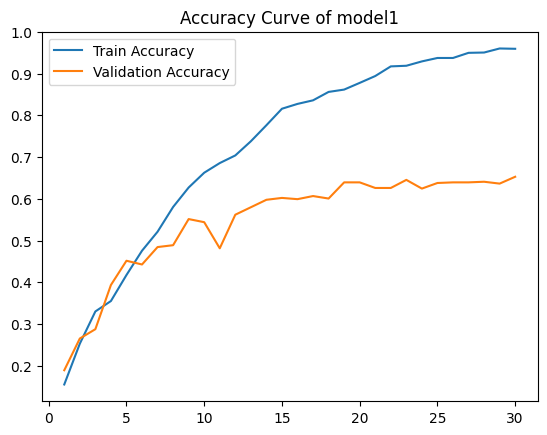

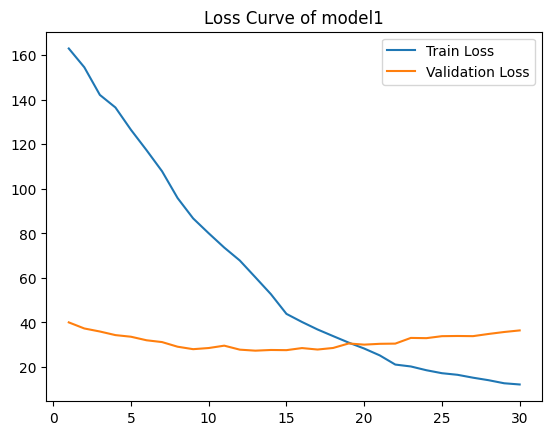

In [18]:
# Accuracy & Loss curve of Basic CNN Model
print("Accuracy & Loss curve of CNN Model (Without BatchNorm & Dropout)")
epochs = range(1, num_epochs+1)

plt.plot(epochs, train_accs1, label="Train Accuracy")
plt.plot(epochs, val_accs1, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve of model1")
plt.savefig("Model1_accuracy_graph.png")
plt.show()

plt.plot(epochs, train_losses1, label="Train Loss")
plt.plot(epochs, val_losses1, label="Validation Loss")
plt.legend()
plt.title("Loss Curve of model1")
plt.savefig("Model1_loss_graph.png")
plt.show()

Accuracy & Loss curve of CNN Model (With BatchNorm & Dropout)


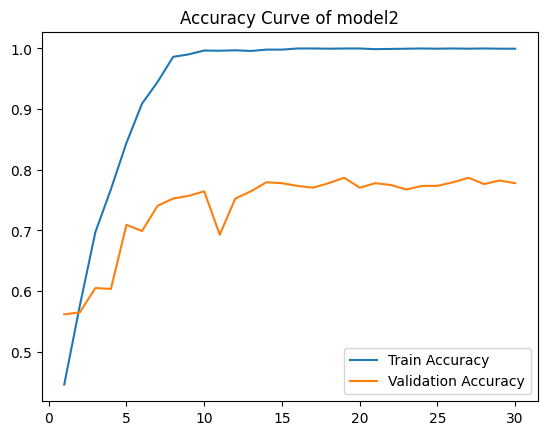

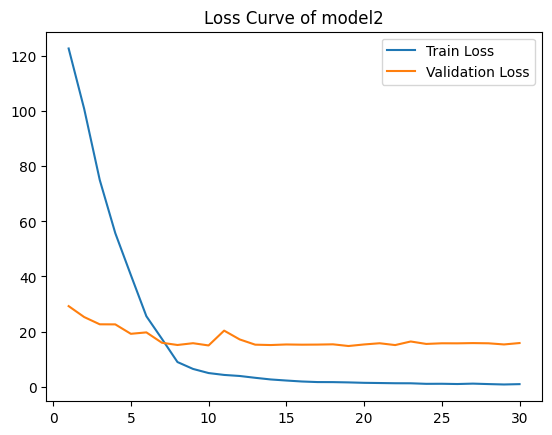

In [19]:
# Accuracy & Loss curve of Improved CNN Model
print("Accuracy & Loss curve of CNN Model (With BatchNorm & Dropout)")
epochs = range(1, num_epochs+1)

plt.plot(epochs, train_accs2, label="Train Accuracy")
plt.plot(epochs, val_accs2, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve of model2")
plt.savefig("Model2_accuracy_graph.png")
plt.show()

plt.plot(epochs, train_losses2, label="Train Loss")
plt.plot(epochs, val_losses2, label="Validation Loss")
plt.legend()
plt.title("Loss Curve of model2")
plt.savefig("Model2_loss_graph.png")
plt.show()

A graph was plotted to compare training and validation accuracy over multiple epochs.

This visualization helped in understanding the learning behavior of the model and identifying issues such as overfitting or underfitting.

**12. Model Evaluation on Test Set**

In [20]:
# For Basic CNN Model
model1.eval()

all_preds1 = []
all_labels1 = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs1 = model1(images)
        _, preds = torch.max(outputs1, 1)

        all_preds1.extend(preds.cpu().numpy())
        all_labels1.extend(labels.numpy())

In [21]:
# For Improved CNN Model
model2.eval()

all_preds2 = []
all_labels2 = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs2 = model2(images)
        _, preds = torch.max(outputs2, 1)

        all_preds2.extend(preds.cpu().numpy())
        all_labels2.extend(labels.numpy())

**13. Classification Report**

In [22]:
# For Basic CNN Model
print(classification_report(all_labels1, all_preds1, target_names=train_dataset.classes))

                  precision    recall  f1-score   support

            Audi       0.63      0.59      0.61       199
   Hyundai Creta       0.58      0.67      0.62        67
Mahindra Scorpio       0.60      0.56      0.58        75
     Rolls Royce       0.44      0.32      0.38        74
           Swift       0.70      0.72      0.71       102
     Tata Safari       0.71      0.74      0.72       106
   Toyota Innova       0.72      0.79      0.76       190

        accuracy                           0.65       813
       macro avg       0.63      0.63      0.62       813
    weighted avg       0.65      0.65      0.65       813



In [24]:
# For Improved CNN Model
print(classification_report(all_labels2, all_preds2, target_names=train_dataset.classes))

                  precision    recall  f1-score   support

            Audi       0.78      0.87      0.82       199
   Hyundai Creta       0.82      0.75      0.78        67
Mahindra Scorpio       0.88      0.80      0.84        75
     Rolls Royce       0.68      0.49      0.57        74
           Swift       0.82      0.82      0.82       102
     Tata Safari       0.85      0.83      0.84       106
   Toyota Innova       0.85      0.90      0.87       190

        accuracy                           0.82       813
       macro avg       0.81      0.78      0.79       813
    weighted avg       0.81      0.82      0.81       813



The final model was evaluated using precision, recall, and F1-score for each class.

These metrics provided a detailed analysis of the model's performance, especially in the presence of class imbalance.

A classification report was generated to summarize the results.

**14. Confusion Matrix Visualization**

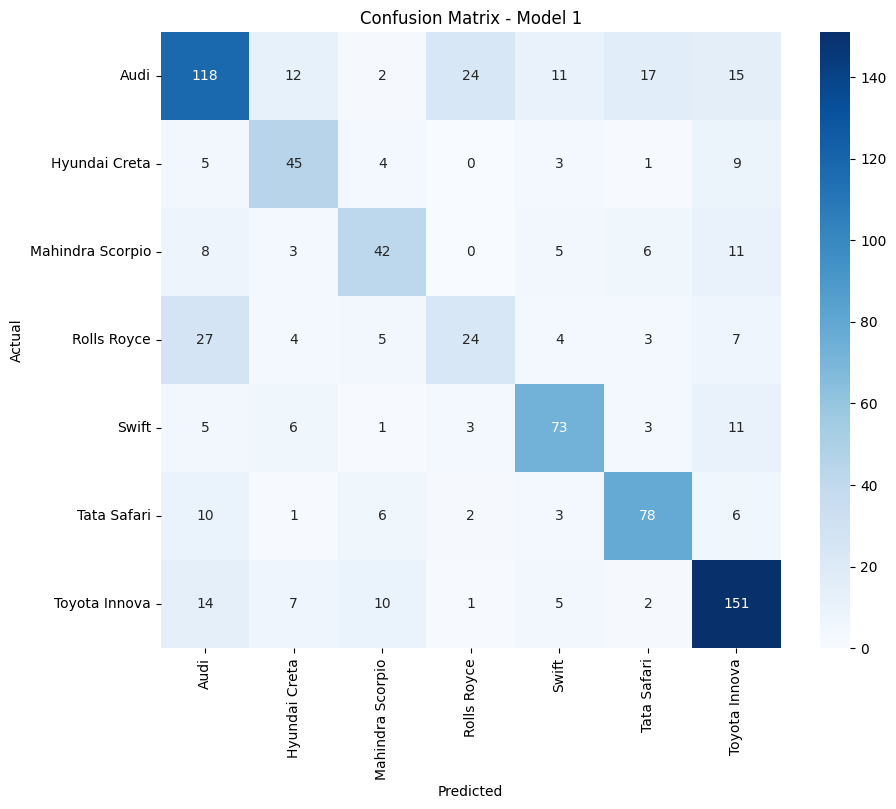

In [25]:
# For Basic CNN Model
cm1 = confusion_matrix(all_labels1, all_preds1)

plt.figure(figsize=(10,8))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Model 1")
plt.savefig("Model1_Confusion_Matrix.png")
plt.show()

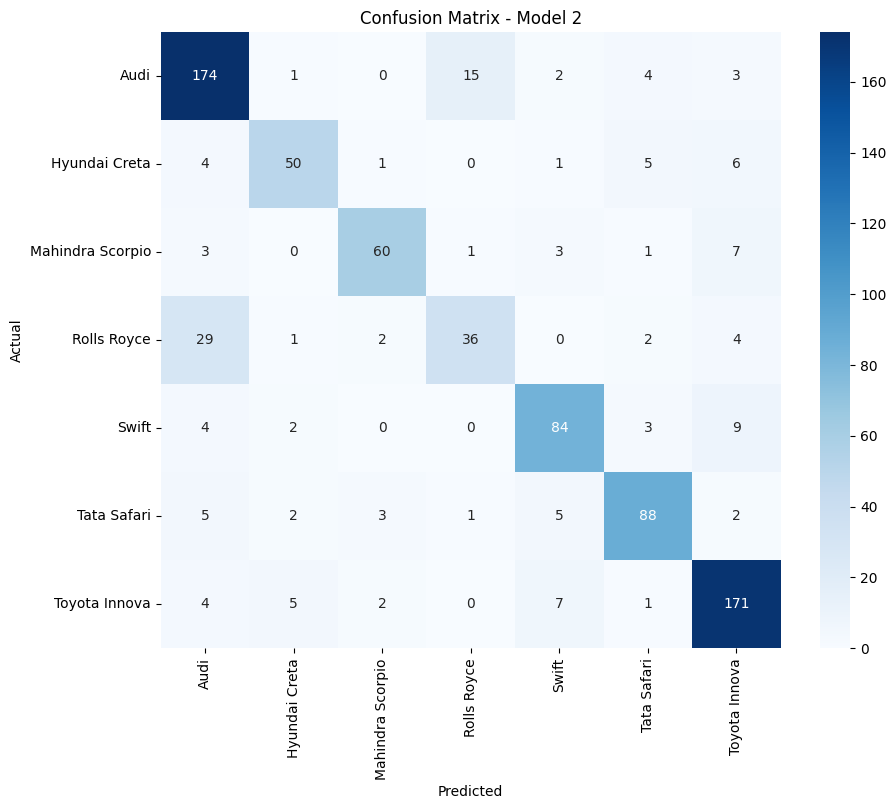

In [26]:
# For Improved CNN Model
cm2 = confusion_matrix(all_labels2, all_preds2)

plt.figure(figsize=(10,8))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Model 2")
plt.savefig("Model2_Confusion_Matrix.png")
plt.show()

**15. Save Model Weights**

In [27]:
torch.save(model1.state_dict(), "cnn_model1.pth")
torch.save(model2.state_dict(), "cnn_model2.pth")

**16. Analysis & Discussion of Results**


In this experiment, two CNN models were evaluated: one without Batch Normalization and Dropout, and another with Batch Normalization and Dropout. The performance difference between these two models is significant.

The CNN model without BatchNorm and Dropout showed a gradual increase in training accuracy, eventually reaching around 95-96%, while validation accuracy plateaued around 65%. This indicates overfitting, where the model learns the training data very well but fails to generalize effectively to unseen data. This is further supported by fluctuations in validation accuracy after epoch 10.

On the other hand, the CNN model with BatchNorm and Dropout demonstrated much better generalization. It achieved nearly 100% training accuracy while maintaining a significantly higher validation accuracy of around 78-79%. The validation performance remained more stable across epochs, indicating that the model is learning more robust and generalized features.

**From the classification reports:**

The model without regularization achieved an overall accuracy of 65%, with lower precision and recall across most classes.
The model with BatchNorm and Dropout achieved a much higher accuracy of 82%, showing consistent improvement in precision, recall, and F1-score.

**Class-wise performance analysis reveals:**

Classes like Toyota Innova, Tata Safari, and Swift performed well in both models, but significantly better in the improved model.
Rolls Royce had the lowest performance in both cases, especially in recall, suggesting difficulty in distinguishing this class, possibly due to fewer samples or high similarity with other classes.
The improved model showed better balance across all classes, indicating reduced bias.

Overall, Batch Normalization helped stabilize and speed up training, while Dropout reduced overfitting by preventing the network from relying too heavily on specific neurons.

**17. Conclusions & Future Work**

**Conclusions:**

In conclusion, adding Batch Normalization and Dropout significantly improved the CNN model's performance. The enhanced model not only achieved higher accuracy (82% vs 65%) but also demonstrated better generalization and stability. This confirms that regularization techniques are essential for improving deep learning models, especially when working with limited or complex datasets.

Despite the improvements, there are still areas for further enhancement. Some classes, such as Rolls Royce, showed relatively low recall, indicating that the model struggles to correctly identify all instances of that category.

**Future Work:**

The following improvements can be considered:

Data augmentation to increase dataset diversity and improve generalization.
Class balancing techniques to handle uneven sample distribution.
Using pretrained models (Transfer Learning) like ResNet or VGG for better feature extraction.
Hyperparameter tuning (learning rate, batch size, number of layers).
Increasing dataset size for better training.

By implementing these improvements, the model performance can be further enhanced, potentially achieving even higher accuracy and robustness.